In [1]:
# Open Yesterday's Project and run all code

# IRIS Flower Classification Project

In [2]:
# Step 1: Load Important modules
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings("ignore")
print("Module Imported Successfully!!")

Module Imported Successfully!!


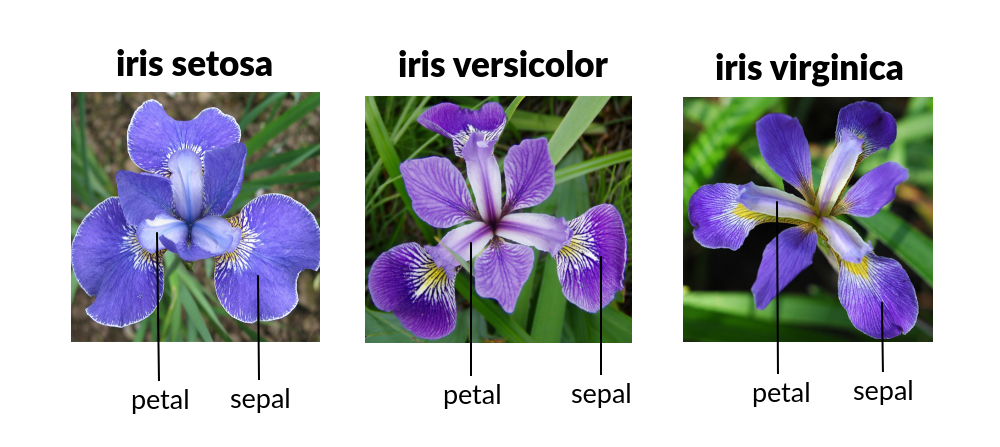

In [3]:
# Step 2: Load datasets
from sklearn.datasets import load_iris
data = load_iris()
# data object is in dict form
data.keys()

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])

In [4]:
# load_iris inbuilt module to download dataset
print(data['DESCR'])

.. _iris_dataset:

Iris plants dataset
--------------------

**Data Set Characteristics:**

:Number of Instances: 150 (50 in each of three classes)
:Number of Attributes: 4 numeric, predictive attributes and the class
:Attribute Information:
    - sepal length in cm
    - sepal width in cm
    - petal length in cm
    - petal width in cm
    - class:
            - Iris-Setosa
            - Iris-Versicolour
            - Iris-Virginica

:Summary Statistics:

============== ==== ==== ======= ===== ====================
                Min  Max   Mean    SD   Class Correlation
============== ==== ==== ======= ===== ====================
sepal length:   4.3  7.9   5.84   0.83    0.7826
sepal width:    2.0  4.4   3.05   0.43   -0.4194
petal length:   1.0  6.9   3.76   1.76    0.9490  (high!)
petal width:    0.1  2.5   1.20   0.76    0.9565  (high!)
============== ==== ==== ======= ===== ====================

:Missing Attribute Values: None
:Class Distribution: 33.3% for each of 3 classes.
:Cr

In [5]:
# Step 3: create dataset
df = pd.DataFrame(data['data'], 
                  columns = data['feature_names'])
df['target'] = data['target']
classes = data['target_names']
print(classes)
df.sample(3)

['setosa' 'versicolor' 'virginica']


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
23,5.1,3.3,1.7,0.5,0
69,5.6,2.5,3.9,1.1,1
107,7.3,2.9,6.3,1.8,2


In [6]:
# Step 4: EDA
df.shape

(150, 5)

In [7]:
df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


In [8]:
df.corr()
# to check corr b/w features vs targets

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
sepal length (cm),1.000000,-0.117570,0.871754,0.817941,0.782561
sepal width (cm),-0.117570,1.000000,-0.428440,-0.366126,-0.426658
petal length (cm),0.871754,-0.428440,1.000000,0.962865,0.949035
petal width (cm),0.817941,-0.366126,0.962865,1.000000,0.956547
target,0.782561,-0.426658,0.949035,0.956547,1.000000


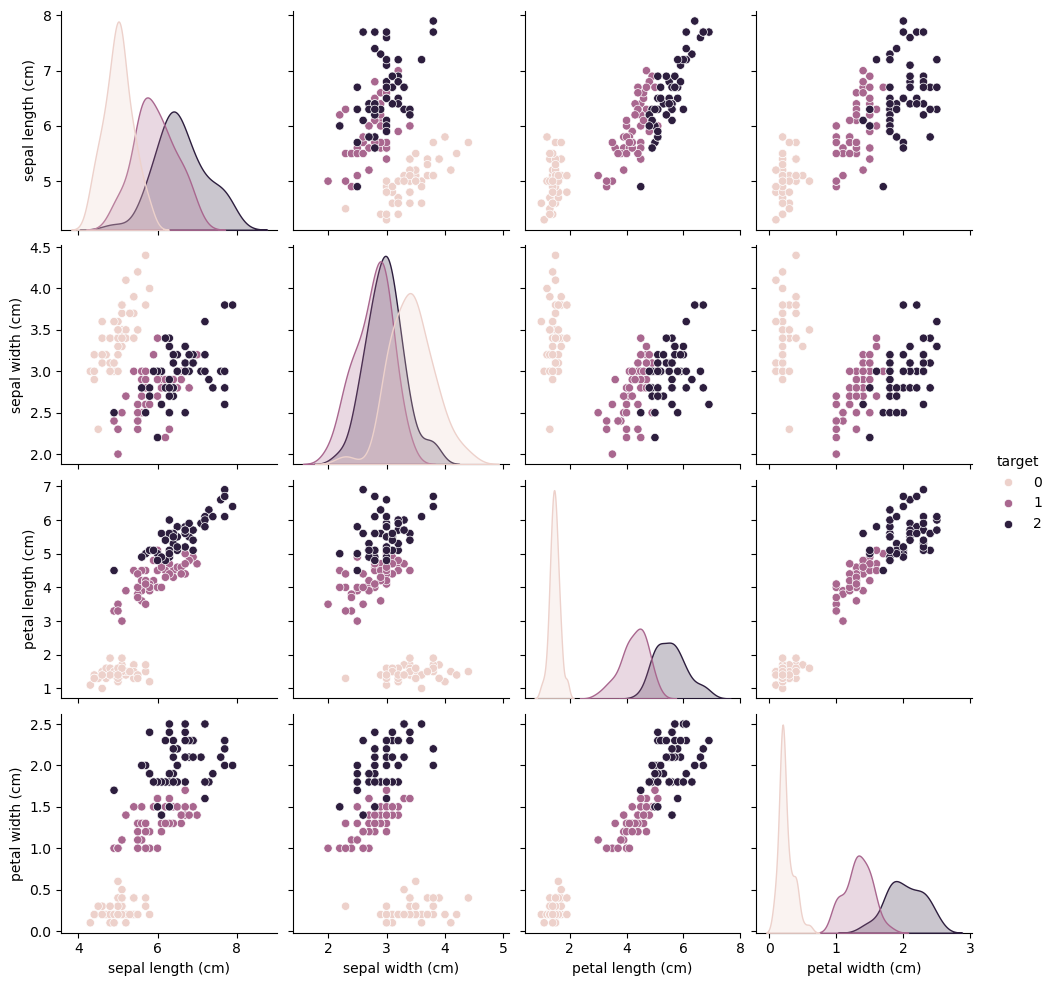

In [9]:
sns.pairplot(data = df, hue = 'target')
plt.show()

In [10]:
# step 5 target imbalance checks
df['target'].value_counts()

target
0    50
1    50
2    50
Name: count, dtype: int64

In [11]:
# Step 6: X and y
X = df.iloc[:,:-1]
y = df.iloc[:,-1]
print(X.shape)
print(y.shape)

(150, 4)
(150,)


In [12]:
df.columns

Index(['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)',
       'petal width (cm)', 'target'],
      dtype='object')

In [13]:
# Step 7: train_test_split
from sklearn.model_selection import train_test_split
X_train,X_test, y_train,y_test = train_test_split(X,y, test_size = 0.2,
                                                  stratify=y, random_state = 42)

print("X_train_Shape: ",X_train.shape)
print("X_test_Shape: ",X_test.shape)
print("y_train_Shape: ",y_train.shape)
print("y_test_Shape: ",y_test.shape)


X_train_Shape:  (120, 4)
X_test_Shape:  (30, 4)
y_train_Shape:  (120,)
y_test_Shape:  (30,)


In [14]:
# Step 8: Different Model building
# Model 1 using Logistic Regression
from sklearn.linear_model import LogisticRegression
model_lr = LogisticRegression()  # using sigmoid
model_lr.fit(X_train,y_train)

LogisticRegression()

In [15]:
# Logistic Model Training and testing score
lr_training_score = model_lr.score(X_train,y_train)
lr_testing_score = model_lr.score(X_test,y_test)
print("Training Score",lr_training_score)
print("Testing Score",lr_testing_score)


Training Score 0.975
Testing Score 0.9666666666666667


In [16]:
# Model 2: using Naive Bayes
from sklearn.naive_bayes import MultinomialNB
model_nv = MultinomialNB()
model_nv.fit(X_train,y_train)

MultinomialNB()

In [17]:
# Naive Bayes Model Training and testing score
nv_training_score = model_nv.score(X_train,y_train)
nv_testing_score = model_nv.score(X_test,y_test)
print("Training Score",nv_training_score)
print("Testing Score",nv_testing_score)


Training Score 0.95
Testing Score 1.0


In [18]:
# Model 3: Decision Tree

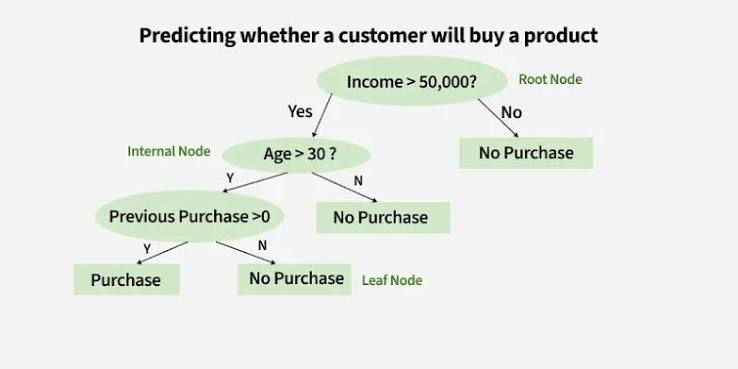

In [19]:
from sklearn.tree import DecisionTreeClassifier
# can be used in both regression or classification problem
model_dt = DecisionTreeClassifier()
model_dt.fit(X_train,y_train)

DecisionTreeClassifier()

In [20]:
# Decision Tree Model Training and testing score
dt_training_score = model_dt.score(X_train,y_train)
dt_testing_score = model_dt.score(X_test,y_test)
print("Training Score",dt_training_score)
print("Testing Score",dt_testing_score)


Training Score 1.0
Testing Score 0.9666666666666667


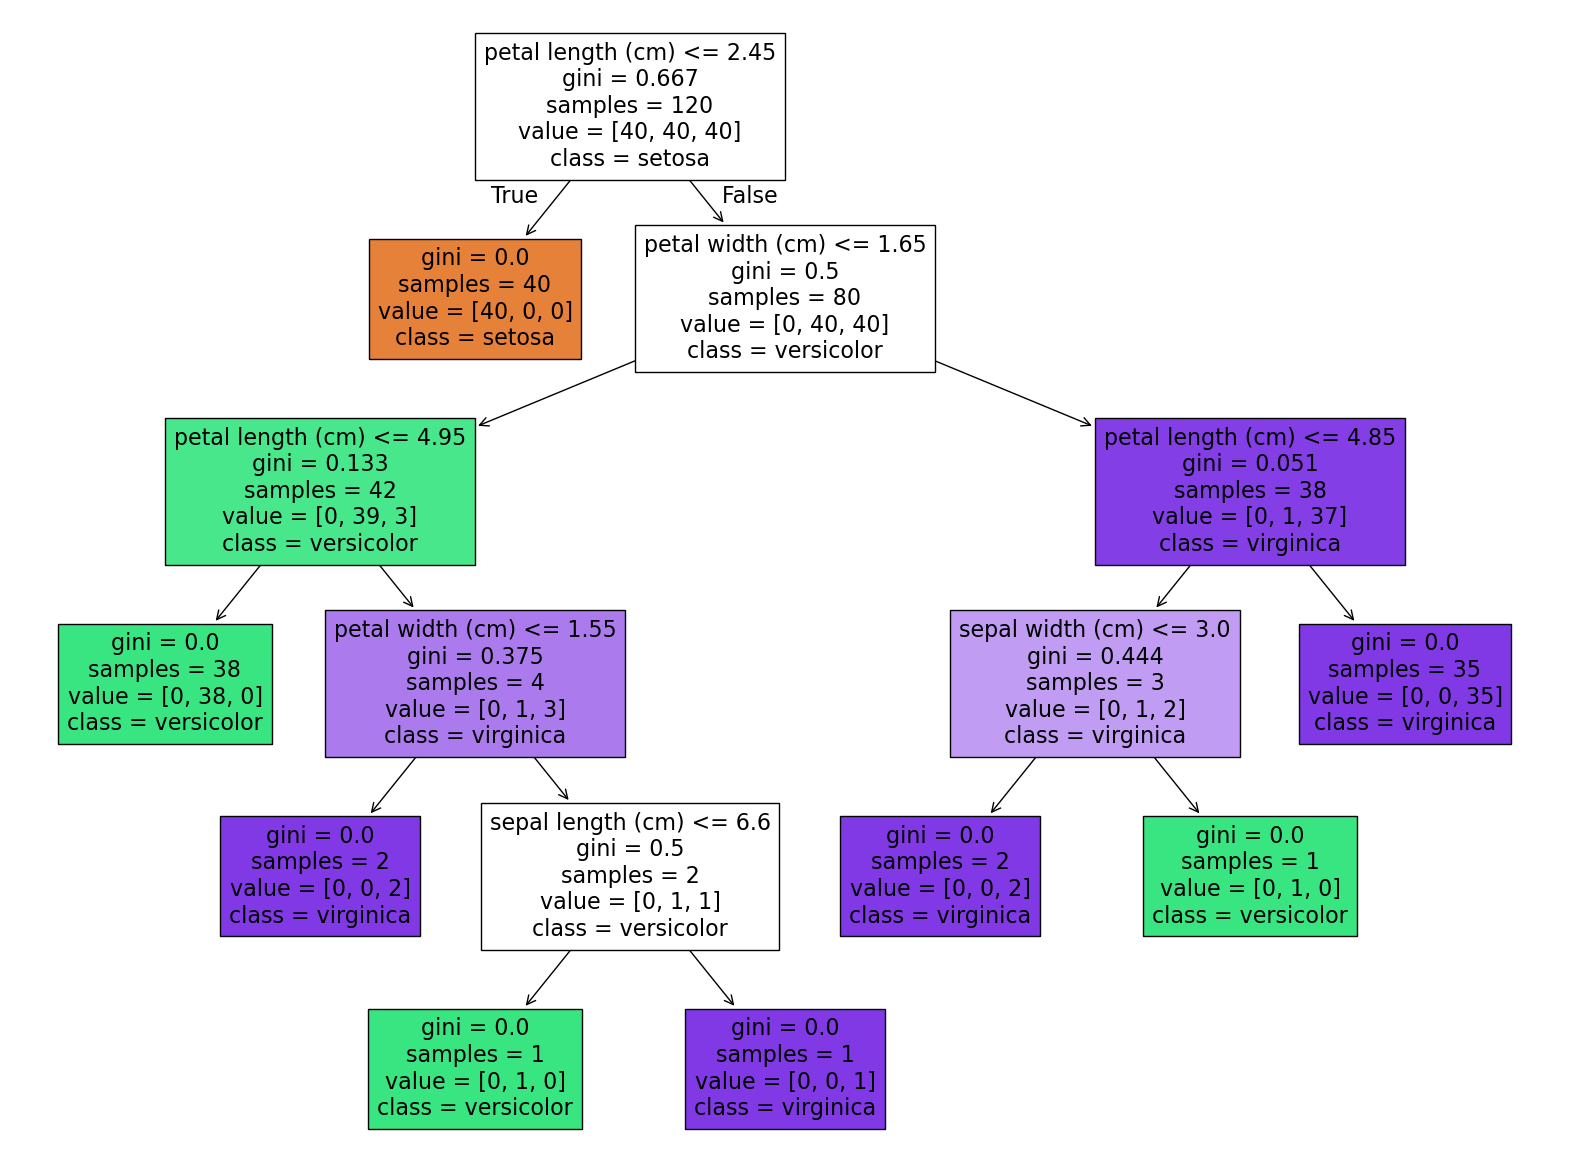

In [21]:
# Plot_tree
from sklearn.tree import plot_tree
plt.figure(figsize = (20,15))
plot_tree(model_dt,
         feature_names=X.columns,
         filled=True,
         class_names=classes)
plt.show()

In [22]:
# Model 4: Model Training using Random Forest
from sklearn.ensemble import RandomForestClassifier
# Collection of multiple trees==> Random_Forest
model_rf = RandomForestClassifier(n_estimators=100)  # 100: Trees
model_rf.fit(X_train,y_train)

RandomForestClassifier()

In [23]:
# Decision Tree Model Training and testing score
rf_training_score = model_rf.score(X_train,y_train)
rf_testing_score = model_rf.score(X_test,y_test)
print("Training Score",rf_training_score)
print("Testing Score",rf_testing_score)


Training Score 1.0
Testing Score 0.9333333333333333


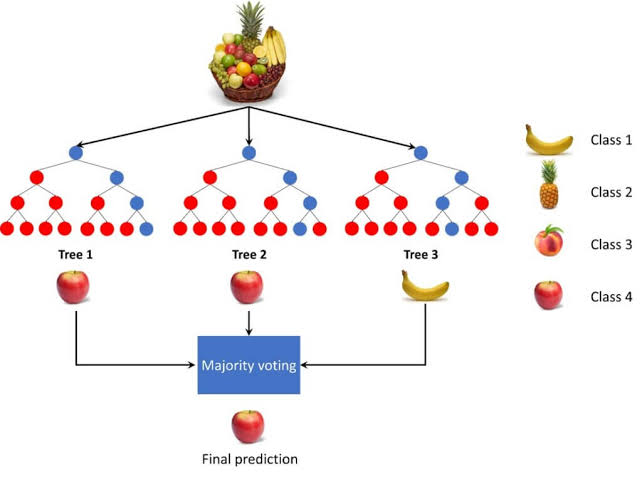

In [24]:
# Model 5 SVM: Support Vector Machine
from sklearn.svm import SVC

model_svm = SVC()
model_svm.fit(X_train,y_train)

SVC()

In [25]:
# SVM Model Training and testing score
svm_training_score = model_svm.score(X_train,y_train)
svm_testing_score = model_svm.score(X_test,y_test)
print("Training Score",svm_training_score)
print("Testing Score",svm_testing_score)


Training Score 0.9833333333333333
Testing Score 0.9666666666666667


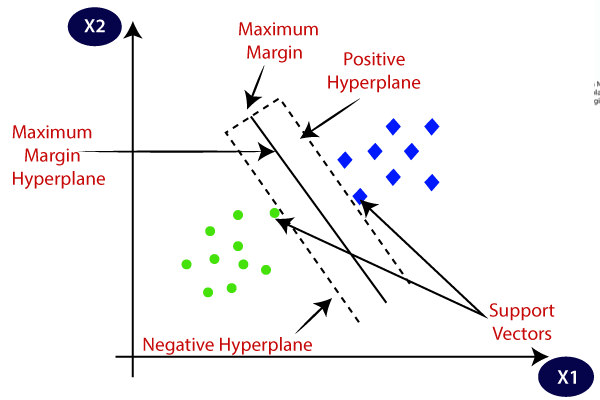

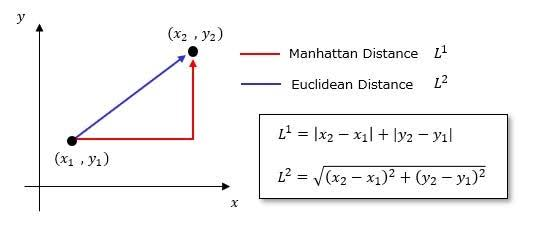

In [28]:
# Model 6: KNN: K-Nearest Neighbors
from sklearn.neighbors import KNeighborsClassifier

model_knn = KNeighborsClassifier(n_neighbors=5)
model_knn.fit(X_train,y_train)

KNeighborsClassifier()

In [29]:
# KNN Model Training and testing score
knn_training_score = model_knn.score(X_train,y_train)
knn_testing_score = model_knn.score(X_test,y_test)
print("Training Score",knn_training_score)
print("Testing Score",knn_testing_score)


Training Score 0.9666666666666667
Testing Score 1.0


In [32]:
all_model_name = ['Logistic Regression',
                 'Naive Bayes',"Decision Tree",
                 "Random Forest","SVM",
                 "KNN"]

all_models = [model_lr,model_nv,model_dt,
              model_rf,model_svm, model_knn]

all_y_pred = []
all_model_accuracy_score = []

count =0
for model in all_models:
    print(f"Checking Model==> {all_model_name[count]}")

    y_predicted = model.predict(X_test)
    acc_score = model.score(X_test,y_test)*100

    all_y_pred.append(y_predicted)
    all_model_accuracy_score.append(acc_score)

    print(f"Score:{acc_score}")
    count += 1
    print('=================\n\n')

Checking Model==> Logistic Regression
Score:96.66666666666667


Checking Model==> Naive Bayes
Score:100.0


Checking Model==> Decision Tree
Score:96.66666666666667


Checking Model==> Random Forest
Score:93.33333333333333


Checking Model==> SVM
Score:96.66666666666667


Checking Model==> KNN
Score:100.0




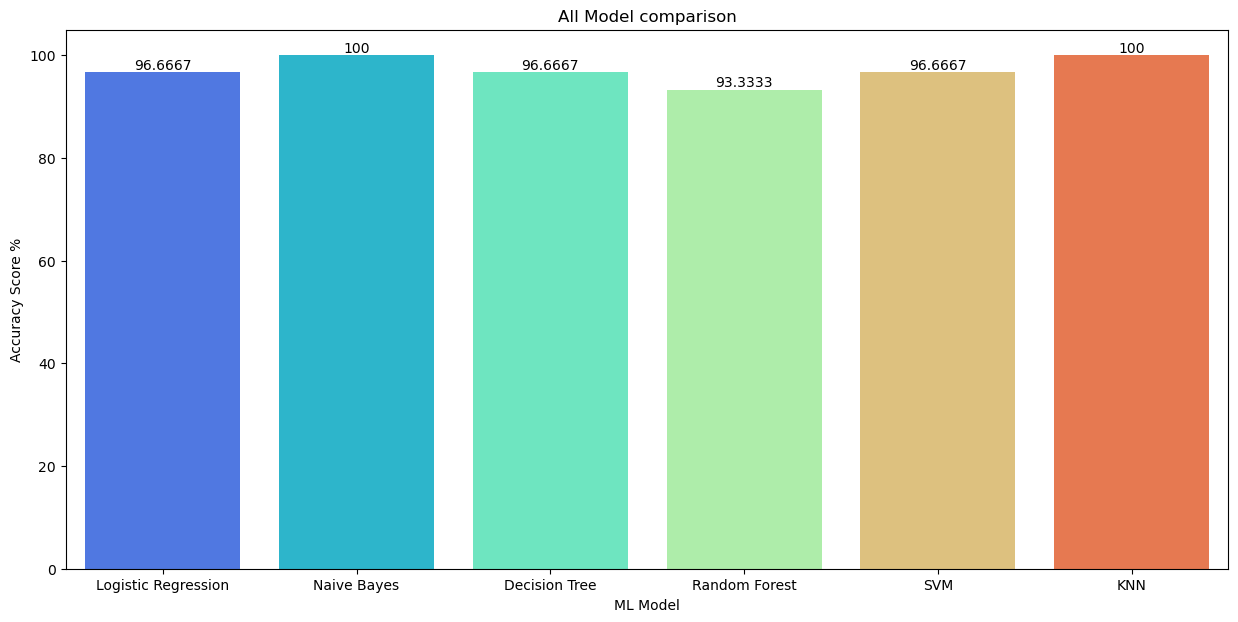

In [36]:
# Model comparison
plt.figure(figsize = (15,7))
plt.title("All Model comparison")
ax = sns.barplot(x = all_model_name, y = all_model_accuracy_score,
           palette=sns.color_palette('rainbow'))

for v in ax.containers:
    plt.bar_label(v)

plt.xlabel("ML Model")
plt.ylabel("Accuracy Score %")
plt.show()

# since each model's score is above 90% we can pick any model for final
# prediction, or group prediction

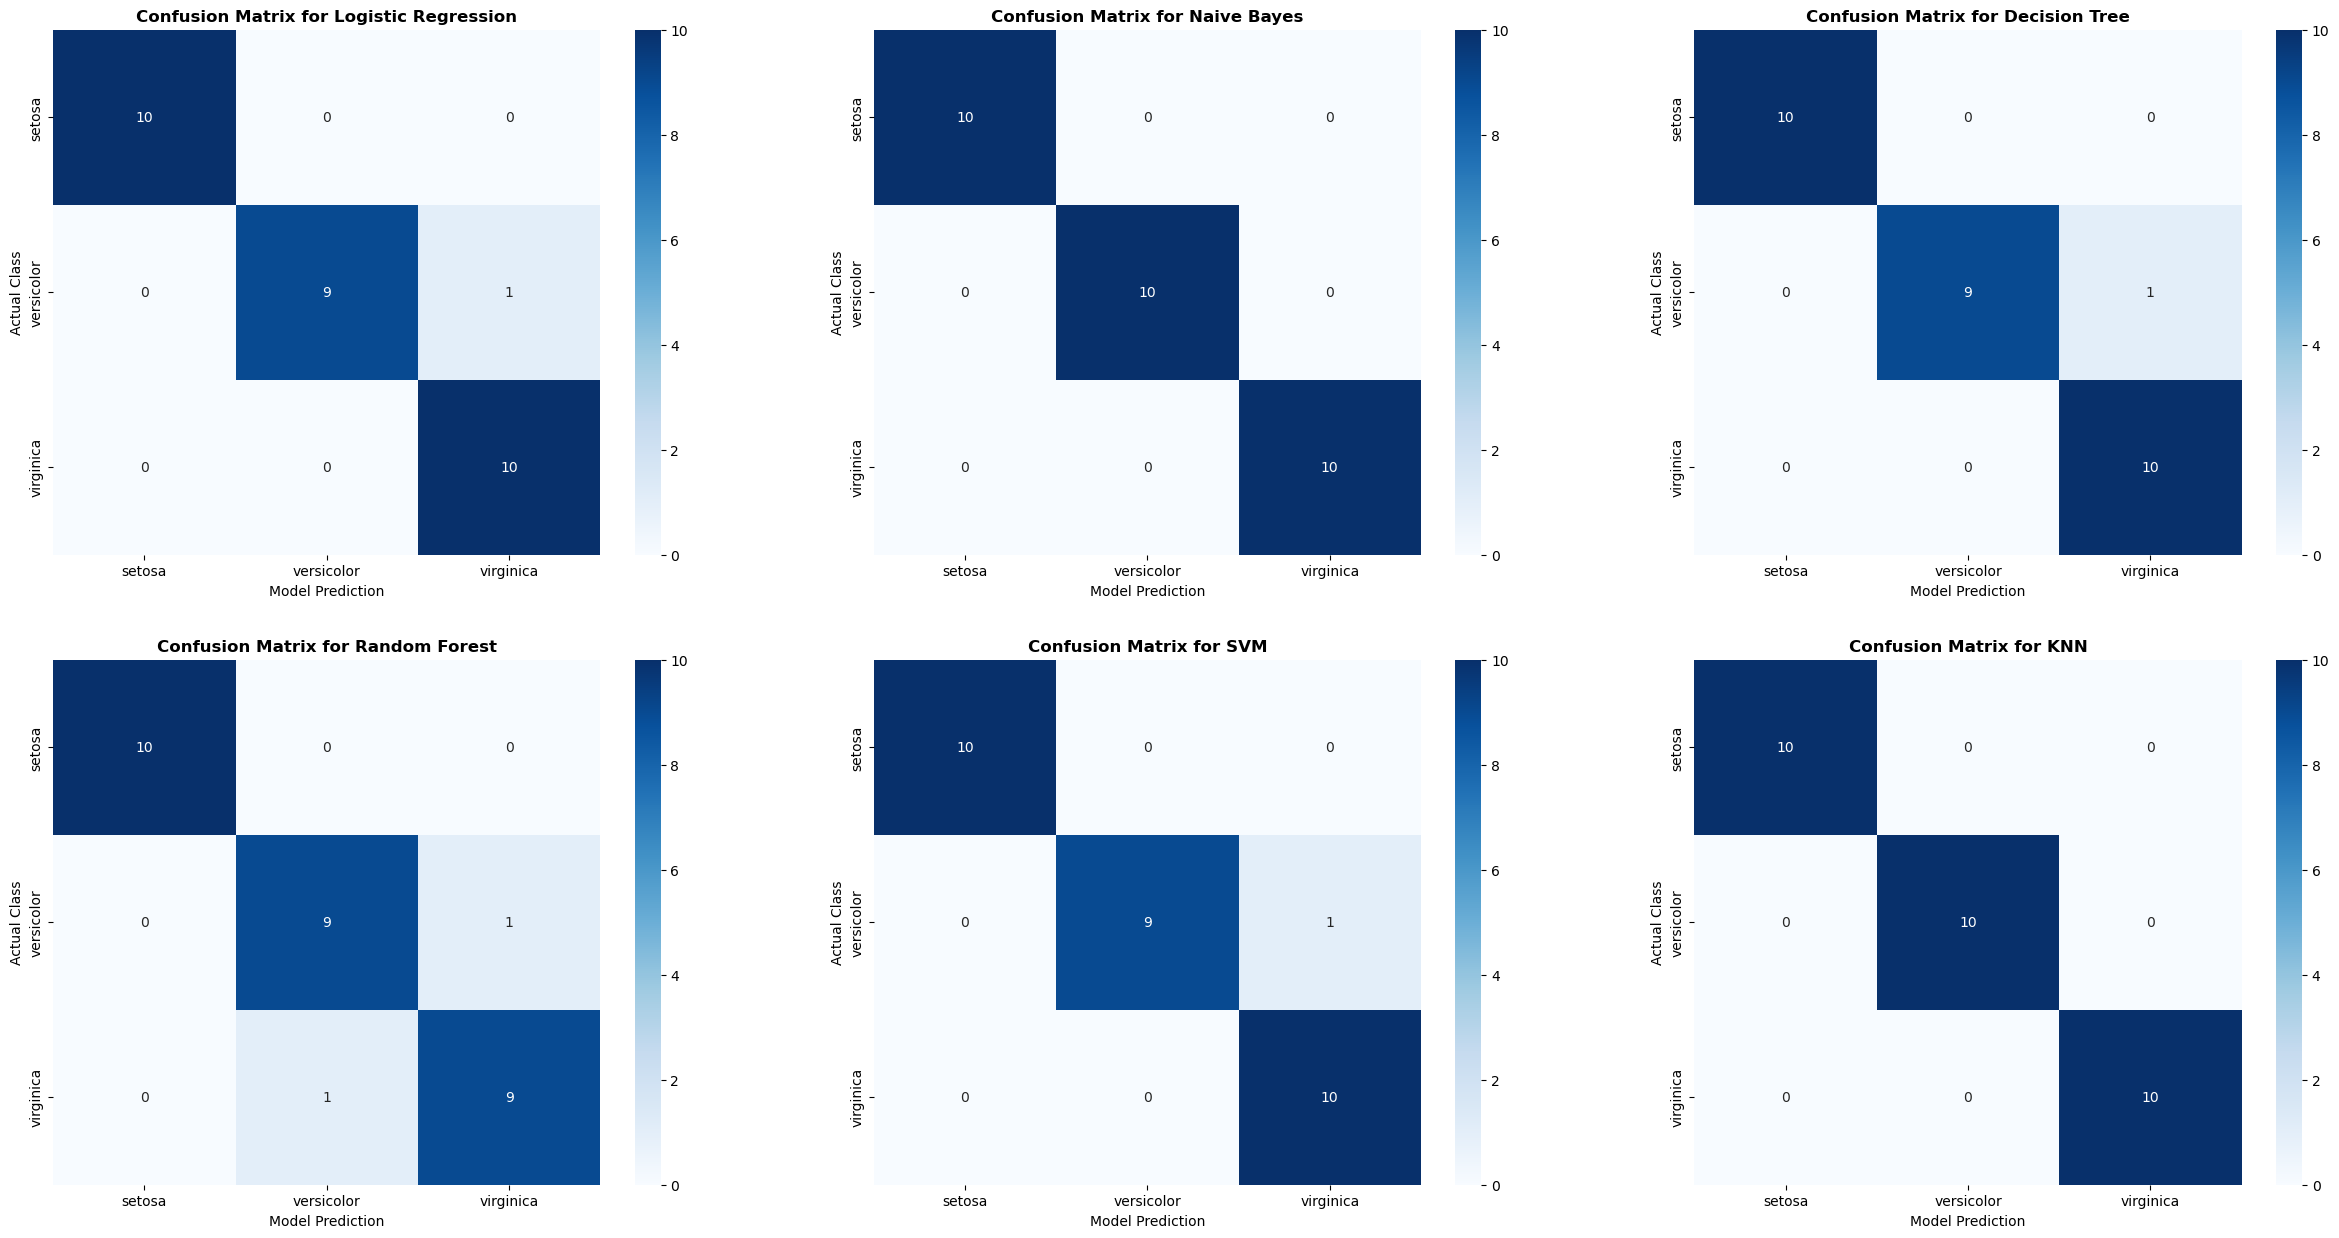

In [38]:
# All Model Confusion Matrix
from sklearn.metrics import confusion_matrix
plt.figure(figsize = (30,15))

for index,y_model in enumerate(all_y_pred):
    plt.subplot(2,3,index + 1)
    plt.title(f"Confusion Matrix for {all_model_name[index]}", fontweight ="bold")
    cm = confusion_matrix(y_test,y_model)
    sns.heatmap(cm, annot = True, cmap='Blues')
    plt.xlabel("Model Prediction")
    plt.ylabel("Actual Class")
    plt.xticks(np.linspace(0.5,2.5,3),classes)
    plt.yticks(np.linspace(0.5,2.5,3),classes)

plt.show()

In [40]:
# Save all Models
import pickle
# pickle: to save objects so that other programming language
# can use that object
for index,model in enumerate(all_models):
    file_name = all_model_name[index]
    with open(f"{file_name}.pkl", 'wb') as f:
        pickle.dump(model,f)
    print(f"Mode: {file_name} Saved Successfully!!")

Mode: Logistic Regression Saved Successfully!!
Mode: Naive Bayes Saved Successfully!!
Mode: Decision Tree Saved Successfully!!
Mode: Random Forest Saved Successfully!!
Mode: SVM Saved Successfully!!
Mode: KNN Saved Successfully!!


In [41]:
# Create new file app.py
!pip install streamlit
# streamlit: to create web based app 
%pip install streamlit
# vscode teminal

  Using cached packaging-24.2-py3-none-any.whl.metadata (3.2 kB)
Using cached packaging-24.2-py3-none-any.whl (65 kB)
  Attempting uninstall: packaging
    Found existing installation: packaging 26.2
    Uninstalling packaging-26.2:
      Successfully uninstalled packaging-26.2


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
spyder 6.0.7 requires ipython!=8.17.1,<9.0.0,>=8.13.0; python_version > "3.8", but you have ipython 9.15.0 which is incompatible.
spyder 6.0.7 requires jedi<0.20.0,>=0.17.2, but you have jedi 0.20.0 which is incompatible.
spyder-kernels 3.0.5 requires ipykernel<7,>=6.29.3, but you have ipykernel 7.3.0 which is incompatible.
spyder-kernels 3.0.5 requires ipython!=8.17.1,<9,>=8.13.0; python_version > "3.8", but you have ipython 9.15.0 which is incompatible.
tensorflow 2.20.0 requires protobuf>=5.28.0, but you have protobuf 4.25.9 which is incompatible.


In [ ]:
# 